# streamdf and Stream Gaps with JAX and PyTorch

This notebook describes how to use the action-angle stream model,
`streamdf`, and the stream-gap model, `streamgapdf`, with
[JAX](https://docs.jax.dev/) and [PyTorch](https://pytorch.org/). See the
[quick start](../getting_started/backends.ipynb) for an introduction to
galpy's backends and the [streamdf tutorial](streamdf.ipynb) for the models
themselves.

`streamdf` models a stream as a distribution in frequency and angle space,
computes the mean track of the stream in configuration space, and samples
and evaluates the DF around that track. On the backends:

* the construction, including the track, is a function of the progenitor's
  orbit and the potential that runs in JAX and is differentiable from end to
  end, when the `streamdf` is set up with a progenitor `Orbit` from a JAX
  array and an `actionAngleIsochroneApprox` instance that integrates with
  diffrax; it can be compiled with `jax.jit`;
* sampling with a backend random key draws by inverse transformation and
  returns backend arrays;
* the DF and its marginal distributions can be evaluated at backend arrays,
  differentiably.

`streamgapdf` adds the effect of the impact of a dark-matter subhalo. Its
construction also runs in JAX, under `jax.jit`, and is differentiable with
respect to the subhalo's parameters, the time of the impact, and the
parameters of the potential.

In [1]:
%matplotlib inline
import time
import warnings

import jax

jax.config.update("jax_enable_x64", True)
from galpy.util import galpyWarning

# galpy's note on streamdf.misalignment's units and NumPy's warnings
warnings.filterwarnings("ignore", category=galpyWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy
import torch

from galpy.actionAngle import actionAngleIsochroneApprox
from galpy.backend import random as grandom
from galpy.df import streamdf, streamgapdf
from galpy.df.streamgapdf import impulse_deltav_hernquist, impulse_deltav_plummer
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential
from galpy.util import conversion

# A GD-1-like stream in a flattened logarithmic halo
prog = [1.56148083, 0.35081535, -1.15481504, 0.88719443, -0.47713334, 0.12019596]
sigv = 0.365 / 220.0
tdisrupt = 4.5 / conversion.time_in_Gyr(220.0, 8.0)
# The action-angle estimator integrates each orbit for tintJ=20 time units at
# ntintJ=1000 steps (galpy's default is 100 and 10000), which suffices here
aA_kwargs = dict(b=0.8, tintJ=20.0, ntintJ=1000)

## Constructing a `streamdf`

With NumPy and galpy's C integrators, the construction is fast on a CPU:

In [2]:
lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)
start = time.perf_counter()
sdf = streamdf(
    sigv,
    progenitor=Orbit(prog),
    pot=lp,
    aA=actionAngleIsochroneApprox(pot=lp, **aA_kwargs),
    leading=True,
    nTrackChunks=11,
    tdisrupt=tdisrupt,
)
print(f"NumPy construction: {time.perf_counter() - start:.1f} s")

NumPy construction: 3.3 s


With a progenitor `Orbit` from a JAX array and an
`actionAngleIsochroneApprox` that integrates with diffrax, the same
construction runs in JAX. Eagerly, this takes a few minutes on a CPU,
because every array operation of the construction (tens of orbit
integrations, action-angle calculations, and their Jacobians) is dispatched
separately; below, we compile it with `jax.jit`. Inside a differentiated or
compiled function, the number of track iterations must be given explicitly
(`nTrackIterations=`), so we give it here as well:

In [3]:
def jax_streamdf(q):
    pot = LogarithmicHaloPotential(normalize=1.0, q=q)
    aA = actionAngleIsochroneApprox(
        pot=pot,
        integrate_method="diffrax",
        integrate_kwargs={"adjoint": "direct"},  # for forward mode, see below
        **aA_kwargs,
    )
    return streamdf(
        sigv,
        progenitor=Orbit(jnp.asarray(prog)),
        pot=pot,
        aA=aA,
        leading=True,
        nTrackChunks=11,
        nTrackIterations=1,
        tdisrupt=tdisrupt,
    )


start = time.perf_counter()
sdf_jax = jax_streamdf(0.9)
print(f"Eager JAX construction: {time.perf_counter() - start:.0f} s")

Eager JAX construction: 154 s


## The stream track

`streamTrack()` returns the track of the stream as a `StreamTrack` object,
parameterized by the angle offset `tp` from the progenitor, with the same
coordinate accessors as an `Orbit` (`x`, `vz`, `R`, `ra`, `ll`, `dist`,
`pmll`, `vlos`, ...) and the covariance of the stream around the track,
`cov(tp, basis=...)`. For the JAX-built stream the accessors return JAX
arrays; the track agrees with the NumPy-built one to the precision of the
action-angle Jacobians (computed by finite differences in NumPy and exactly
in JAX):

In [4]:
track = sdf.streamTrack()
track_jax = sdf_jax.streamTrack()
for tr in [track, track_jax]:
    tr.turn_physical_on()  # kpc, km/s, and deg, also for the covariance
tp = track.tp_grid()
print(type(track_jax.x(tp)))
for c in ["x", "z", "vz", "ll", "bb", "dist"]:
    print(
        f"{c:>4}: largest difference",
        f"{numpy.max(numpy.fabs(numpy.asarray(getattr(track_jax, c)(tp)) - getattr(track, c)(tp))):.1e}",
    )
cov = track_jax.cov(tp[len(tp) // 2], basis="galsky")  # (ll,bb,dist,pmll,pmbb,vlos)
print(
    "width in b [deg], distance [kpc], vlos [km/s]:",
    numpy.sqrt(numpy.diag(cov))[[1, 2, 5]],
)

<class 'jaxlib._jax.ArrayImpl'>
   x: largest difference 1.1e-03
   z: largest difference 1.6e-03
  vz: largest difference 1.6e-02


  ll: largest difference 4.3e-03
  bb: largest difference 6.5e-03
dist: largest difference 3.2e-04


width in b [deg], distance [kpc], vlos [km/s]: [0.33551286 0.04225811 0.94103896]


A sample drawn with a JAX or PyTorch key (`sample` returns
`(R,vR,vT,z,vz,phi)` as an array of shape `(6,n)` of that backend) lies
along the track; `StreamTrack.plot` draws the track with a band of
$\pm1\sigma$ from its covariance:

<class 'jaxlib._jax.ArrayImpl'> (6, 1000)


<class 'torch.Tensor'>


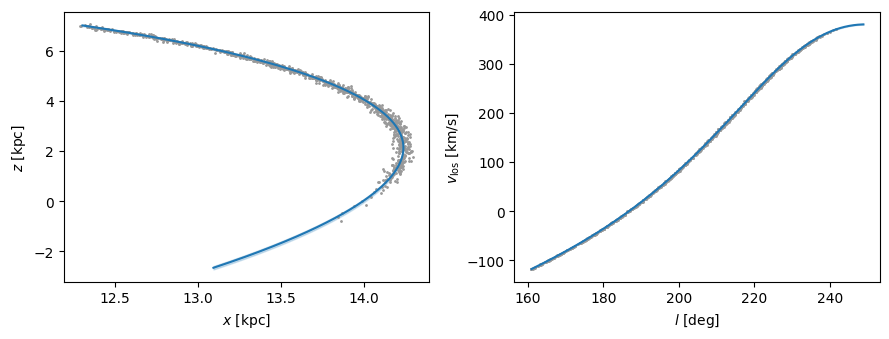

In [5]:
RvR = sdf.sample(n=1000, key=grandom.key(3, backend="jax"))
print(type(RvR), RvR.shape)
RvR_t = sdf.sample(n=1000, key=grandom.key(3, backend="torch"))
print(type(RvR_t))
so = Orbit(numpy.asarray(RvR).T)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
so.turn_physical_on(ro=8.0, vo=220.0)
ax1.plot(so.x(), so.z(), ".", ms=2, color="0.6")
plt.sca(ax1)
track.plot(d1="x", d2="z", spread=1, color="C0")
ax1.set_xlabel(r"$x$ [kpc]")
ax1.set_ylabel(r"$z$ [kpc]")
ax2.plot(so.ll(), so.vlos(), ".", ms=2, color="0.6")
plt.sca(ax2)
track.plot(d1="ll", d2="vlos", spread=1, color="C0")
ax2.set_xlabel(r"$l$ [deg]")
ax2.set_ylabel(r"$v_\mathrm{los}$ [km/s]")
fig.tight_layout()

## Evaluating the DF on backend arrays

The DF and its marginal distributions can be evaluated at backend arrays
and differentiated. For example, the density along the stream as a function
of the parallel angle offset from the progenitor, the mean parallel
frequency, and the derivative of the density, vectorized with `jax.vmap`:

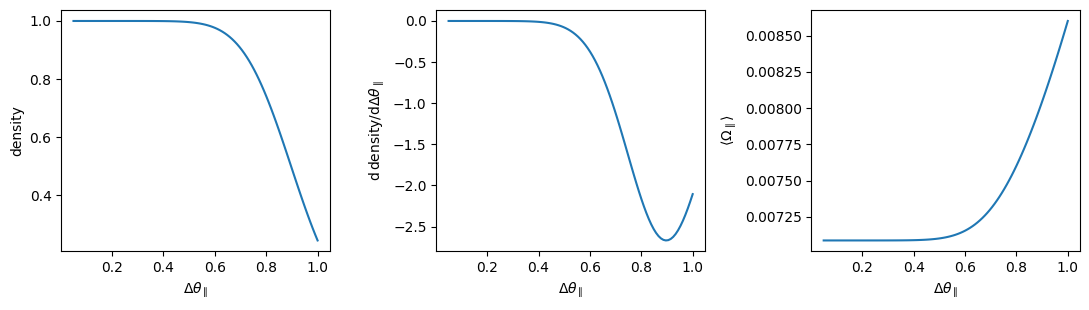

In [6]:
dangle = jnp.linspace(0.05, 1.0, 101)
dens = jax.vmap(sdf.density_par)(dangle)
ddens = jax.vmap(jax.grad(sdf.density_par))(dangle)
mOpar = sdf.meanOmega(dangle, oned=True)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3.2))
ax1.plot(dangle, dens)
ax1.set_ylabel("density")
ax2.plot(dangle, ddens)
ax2.set_ylabel(r"$\mathrm{d}\,\mathrm{density}/\mathrm{d}\Delta\theta_\parallel$")
ax3.plot(dangle, mOpar)
ax3.set_ylabel(r"$\langle\Omega_\parallel\rangle$")
for ax in (ax1, ax2, ax3):
    ax.set_xlabel(r"$\Delta\theta_\parallel$")
fig.tight_layout()

The derivative agrees with a finite difference, and the same works with
PyTorch:

In [7]:
h = 1e-6
print(
    ddens[50],
    (sdf.density_par(dangle[50] + h) - sdf.density_par(dangle[50] - h)) / (2.0 * h),
)
da = torch.tensor(float(dangle[50]), dtype=torch.float64, requires_grad=True)
sdf.density_par(da).backward()
print(da.grad)

-0.12069385470960987 -0.1206938547437808
tensor(-0.1207, dtype=torch.float64)


The full DF can be evaluated at backend phase-space positions as well:

In [8]:
print(sdf(*RvR[:, :5]))

[ 7.71659913 10.2335268   9.9491602   7.41281539  8.68670254]


## The derivative of the track with respect to the potential

The JAX construction is differentiable with respect to the parameters of
the potential and of the progenitor's orbit. We compile the construction
together with its forward-mode derivative (`jax.jvp`) with respect to the
flattening $q$ of the halo, and evaluate $x$ and $z$ along the track. As in
the [orbits notebook](../orbits/backends.ipynb), forward mode uses diffrax's
direct adjoint, which we selected explicitly above so that this runs with
every version of JAX:

In [9]:
def track_xz(q):
    tr = jax_streamdf(q).streamTrack()
    tp = tr.tp_grid()[::50]
    return tp, jnp.stack([tr.x(tp), tr.z(tp)])


track_and_derivative = jax.jit(lambda q: jax.jvp(track_xz, (q,), (1.0,)))
start = time.perf_counter()
(tp, xz), (_, dxz_dq) = track_and_derivative(0.9)
print(f"First call (compiles): {time.perf_counter() - start:.0f} s")
start = time.perf_counter()
track_and_derivative(0.9)
print(f"Second call: {time.perf_counter() - start:.1f} s")

First call (compiles): 111 s


Second call: 7.0 s


The derivative agrees with finite differences of the same computation, for
two step sizes:

h = 1e-05: largest relative difference 1.3e-06


h = 3e-06: largest relative difference 1.5e-06


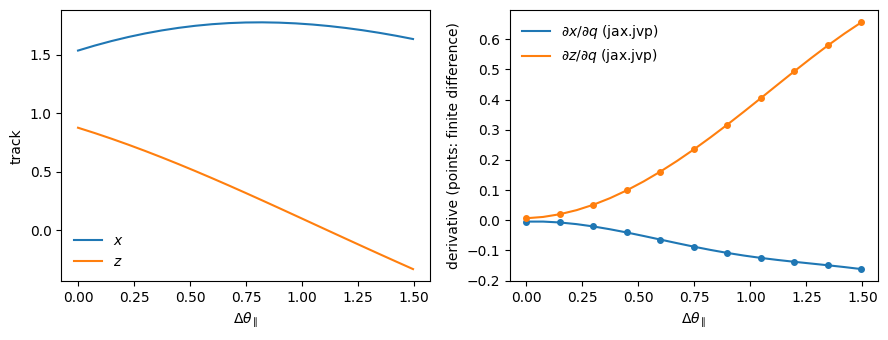

In [10]:
fd = {}
for h in [1e-5, 3e-6]:
    fd[h] = (
        track_and_derivative(0.9 + h)[0][1] - track_and_derivative(0.9 - h)[0][1]
    ) / (2.0 * h)
    print(
        f"h = {h:.0e}: largest relative difference",
        f"{numpy.max(numpy.fabs(dxz_dq - fd[h])) / numpy.max(numpy.fabs(dxz_dq)):.1e}",
    )
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
for i, c in enumerate(["x", "z"]):
    ax1.plot(tp, xz[i], label=rf"${c}$")
    ax2.plot(tp, dxz_dq[i], label=rf"$\partial {c}/\partial q$ (jax.jvp)")
    ax2.plot(tp[::2], fd[1e-5][i][::2], "o", color=f"C{i}", ms=4)
ax1.set_xlabel(r"$\Delta\theta_\parallel$")
ax1.set_ylabel("track")
ax1.legend(frameon=False)
ax2.set_xlabel(r"$\Delta\theta_\parallel$")
ax2.set_ylabel(r"derivative (points: finite difference)")
ax2.legend(frameon=False)
fig.tight_layout()

Reverse mode (`jax.grad`) works as well and is the efficient choice for a
scalar, such as a likelihood, that depends on many parameters.

The derivatives of stream models deserve a general comment. Because a stream
model is a generative model, the derivative of the track with respect to a
parameter can be taken either with the stream's stars held fixed or by
letting them move with the parameter. galpy's derivatives are of the second
kind, which is what a finite difference of the full model computes; the
first is not a physical quantity.

## Stream gaps: `streamgapdf`

The stream-gap model of Sanders, Bovy, & Erkal (2016), `streamgapdf`,
computes the velocity kick that a passing subhalo imparts along a stream in
the impulse approximation and propagates it through the action-angle model.

### The kick kernels

The kick kernels for Plummer and Hernquist subhalos run on the backends and
are differentiable with respect to the parameters of the impact. For a
straight stream moving along $y$ with unit speed and a Plummer subhalo with
mass `GM`, scale radius `rs`, velocity `w`, and impact parameter `b`, the kick
along the stream and its derivative with respect to the impact parameter:

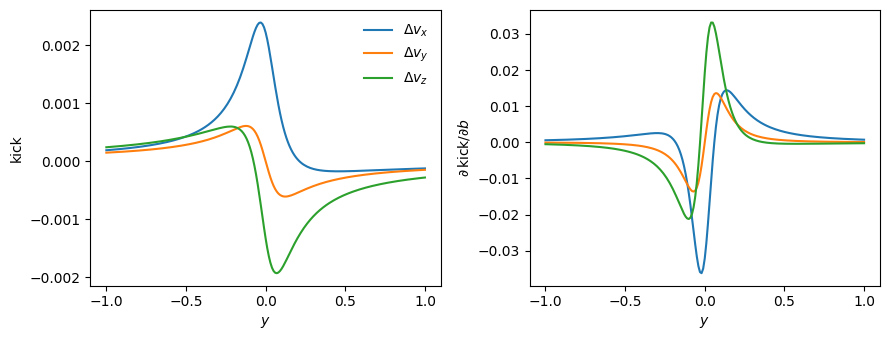

In [11]:
y = jnp.linspace(-1.0, 1.0, 201)  # position along the stream
v = jnp.tile(jnp.array([0.0, 1.0, 0.0]), (len(y), 1))  # stream velocity
w = jnp.array([0.3, -0.2, 0.5])  # subhalo velocity
GM, rs, b = 1e-4, 0.02, 0.05
dv = impulse_deltav_plummer(v, y, b, w, GM, rs)
ddv_db = jax.jacfwd(lambda b: impulse_deltav_plummer(v, y, b, w, GM, rs))(b)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
for ii, label in enumerate([r"$\Delta v_x$", r"$\Delta v_y$", r"$\Delta v_z$"]):
    ax1.plot(y, dv[:, ii], label=label)
    ax2.plot(y, ddv_db[:, ii])
ax1.set_xlabel(r"$y$")
ax1.set_ylabel("kick")
ax1.legend(frameon=False)
ax2.set_xlabel(r"$y$")
ax2.set_ylabel(r"$\partial\,\mathrm{kick} / \partial b$")
fig.tight_layout()

The derivative agrees with a finite difference of the NumPy kernel, and the
Hernquist kernel works in the same way, here with PyTorch:

In [12]:
vn, yn, wn = numpy.array(v), numpy.array(y), numpy.array(w)
h = 1e-6
fd_kick = (
    impulse_deltav_plummer(vn, yn, b + h, wn, GM, rs)
    - impulse_deltav_plummer(vn, yn, b - h, wn, GM, rs)
) / (2.0 * h)
print(numpy.max(numpy.fabs(ddv_db - fd_kick)) / numpy.max(numpy.fabs(fd_kick)))
bt = torch.tensor(b, dtype=torch.float64, requires_grad=True)
dv_t = impulse_deltav_hernquist(
    torch.as_tensor(vn), torch.as_tensor(yn), bt, torch.as_tensor(wn), GM, rs
)
dv_t[:, 0].sum().backward()
print(bt.grad)

2.8212892252377435e-10
tensor(0.2494, dtype=torch.float64)


### A stream gap in JAX

The construction of a `streamgapdf` as a whole runs in JAX with a
progenitor `Orbit` from a JAX array and an `actionAngleIsochroneApprox` that
integrates with diffrax, as for `streamdf` above. We set up the example of
Sanders et al. (2016): the trailing arm of a stream that is hit 0.88 Gyr ago
by a $10^8\,M_\odot$ Plummer subhalo. The function below builds the
`streamgapdf` for a vector of parameters: the subhalo's mass `GM`, its
scale radius `rs`, the impact parameter `impactb`, the three components of
the subhalo's velocity `subhalovel`, the time of the impact `timpact`, and
the flattening $q$ of the halo. It returns the density and the mean
parallel frequency along the stream. Inside a compiled function, the number
of track chunks around the impact must be given explicitly
(`nTrackChunksImpact=`):

First call (compiles): 178 s


Second call: 2.4 s


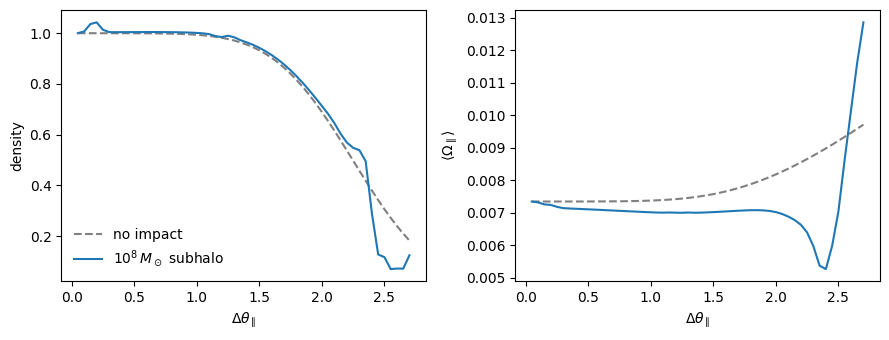

In [13]:
V0, R0 = 220.0, 8.0
prog_gap = [2.6556151742081835, 0.2183747276300308, 0.67876510797240575]
prog_gap += [-2.0143395648974671, -0.3273737682604374, 0.24218273922966019]
p0 = numpy.array(
    [
        10.0**8.0 / conversion.mass_in_msol(V0, R0),  # GM
        0.625 / R0,  # rs
        0.1 / R0,  # impactb
        6.82200571 / V0,  # subhalovel
        132.7700529 / V0,
        149.4174464 / V0,
        0.88 / conversion.time_in_Gyr(V0, R0),  # timpact
        0.9,  # q
    ]
)
names = ["GM", "rs", "impactb", "w_x", "w_y", "w_z", "timpact", "q"]
dangle_gap = jnp.linspace(0.05, 2.7, 54)


def gap_model(p):
    pot = LogarithmicHaloPotential(normalize=1.0, q=p[7])
    aA = actionAngleIsochroneApprox(
        pot=pot,
        integrate_method="diffrax",
        integrate_kwargs={"adjoint": "direct"},
        **aA_kwargs,
    )
    sgdf = streamgapdf(
        0.365 * (10.0 / 2.0) ** (1.0 / 3.0) / V0,
        progenitor=Orbit(jnp.asarray(prog_gap)),
        pot=pot,
        aA=aA,
        leading=False,
        nTrackChunks=5,
        nTrackIterations=1,
        nTrackChunksImpact=5,
        sigMeanOffset=4.5,
        tdisrupt=10.88 / conversion.time_in_Gyr(V0, R0),
        impact_angle=-2.34,
        GM=p[0],
        rs=p[1],
        impactb=p[2],
        subhalovel=p[3:6],
        timpact=p[6],
    )
    return jnp.stack(
        [sgdf.density_par(dangle_gap), sgdf.meanOmega(dangle_gap, oned=True)]
    )


gap_model_jit = jax.jit(gap_model)
start = time.perf_counter()
gap = gap_model_jit(p0)
print(f"First call (compiles): {time.perf_counter() - start:.0f} s")
start = time.perf_counter()
no_gap = gap_model_jit(p0 * numpy.array([0.0, 1, 1, 1, 1, 1, 1, 1]))  # GM = 0
print(f"Second call: {time.perf_counter() - start:.1f} s")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, i, label in [
    (ax1, 0, "density"),
    (ax2, 1, r"$\langle\Omega_\parallel\rangle$"),
]:
    ax.plot(dangle_gap, no_gap[i], "--", color="0.5", label="no impact")
    ax.plot(dangle_gap, gap[i], label=r"$10^8\,M_\odot$ subhalo")
    ax.set_xlabel(r"$\Delta\theta_\parallel$")
    ax.set_ylabel(label)
ax1.legend(frameon=False)
fig.tight_layout()

The derivatives of the density and the mean frequency along the stream with
respect to all eight parameters follow from `jax.jacfwd`. We compile a
function that returns both the model and its Jacobian:

In [14]:
def gap_model_and_jacobian(p):
    return jax.vmap(lambda t: jax.jvp(gap_model, (p,), (t,)), out_axes=(None, -1))(
        jnp.eye(len(p))
    )


gap_model_and_jacobian_jit = jax.jit(gap_model_and_jacobian)
start = time.perf_counter()
_, jac = gap_model_and_jacobian_jit(p0)
print(f"First call (compiles): {time.perf_counter() - start:.0f} s")

First call (compiles): 216 s


Every column agrees with a central finite difference of the compiled model
(steps of $10^{-4}$ times each parameter):

      GM: largest relative difference 1.0e-08


      rs: largest relative difference 6.3e-08


 impactb: largest relative difference 4.7e-08


     w_x: largest relative difference 7.7e-08


     w_y: largest relative difference 3.3e-09


     w_z: largest relative difference 1.8e-08


 timpact: largest relative difference 3.4e-06


       q: largest relative difference 4.0e-05


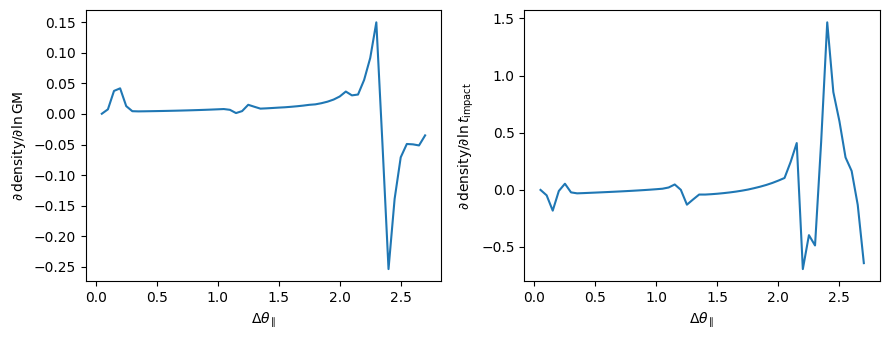

In [15]:
for i, name in enumerate(names):
    dp = numpy.zeros_like(p0)
    dp[i] = 1e-4 * numpy.fabs(p0[i])
    fd_gap = (gap_model_jit(p0 + dp) - gap_model_jit(p0 - dp)) / (2.0 * dp[i])
    rel = numpy.max(numpy.fabs(jac[..., i] - fd_gap)) / numpy.max(numpy.fabs(fd_gap))
    print(f"{name:>8}: largest relative difference {rel:.1e}")
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, i, label in [(axs[0], 0, r"\mathrm{GM}"), (axs[1], 6, r"t_\mathrm{impact}")]:
    ax.plot(dangle_gap, jac[0, :, i] * p0[i])
    ax.set_xlabel(r"$\Delta\theta_\parallel$")
    ax.set_ylabel(r"$\partial\,\mathrm{density}/\partial \ln " + label + "$")
fig.tight_layout()

### Fitting the mass of the subhalo

As a small application, we fit the mass of the subhalo to a mock
measurement of the density along the gapped stream, generated with the
$10^8\,M_\odot$ subhalo above and with Gaussian noise. We fit $\ln
\mathrm{GM}$ with Gauss-Newton iterations, which use the derivative of the
model density with respect to GM from the compiled Jacobian, starting from
a subhalo three times less massive:

In [16]:
rng = numpy.random.default_rng(1)
sigma_dens = 0.01
dens_obs = numpy.asarray(gap[0]) + sigma_dens * rng.standard_normal(len(dangle_gap))
lnGM = numpy.log(p0[0] / 3.0)
for ii in range(5):
    p = p0.copy()
    p[0] = numpy.exp(lnGM)
    model, jac_p = gap_model_and_jacobian_jit(p)
    r = (numpy.asarray(model[0]) - dens_obs) / sigma_dens
    J = numpy.asarray(jac_p[0, :, 0]) * p[0] / sigma_dens  # d r / d lnGM
    print(
        f"Iteration {ii}: GM = {p[0] * conversion.mass_in_msol(V0, R0):.4e} Msun, chi^2 = {numpy.sum(r**2):.1f}"
    )
    lnGM -= numpy.dot(J, r) / numpy.dot(J, J)
print(
    f"Best fit: GM = {numpy.exp(lnGM) * conversion.mass_in_msol(V0, R0):.4e} Msun "
    f"+/- {numpy.exp(lnGM) / numpy.sqrt(numpy.dot(J, J)) * conversion.mass_in_msol(V0, R0):.1e} Msun "
    f"(true value: {p0[0] * conversion.mass_in_msol(V0, R0):.4e} Msun)"
)

Iteration 0: GM = 3.3333e+07 Msun, chi^2 = 1017.0


Iteration 1: GM = 1.1264e+08 Msun, chi^2 = 119.1


Iteration 2: GM = 9.6680e+07 Msun, chi^2 = 40.8


Iteration 3: GM = 9.8643e+07 Msun, chi^2 = 40.2


Iteration 4: GM = 9.8639e+07 Msun, chi^2 = 40.2
Best fit: GM = 9.8639e+07 Msun +/- 2.6e+06 Msun (true value: 1.0000e+08 Msun)
